# Clinical Trial Efficacy and Safety Analysis

"""
This project analyzes a synthetic clinical trial dataset
comparing Drug A with a placebo.

The analysis focuses on:
- Data quality
- Participant demographics
- Treatment efficacy
- Biomarker changes
- Treatment response
- Adverse events
- Basic statistical analysis

Note:
The dataset is entirely synthetic and contains no real
patient information.
"""

# 1. Introduction

This project performs an exploratory and statistical analysis
of a synthetic clinical trial dataset comparing Drug A with
a placebo.

The analysis evaluates participant characteristics, treatment
response, biomarker changes, and adverse events.

The dataset is synthetic and is intended solely for educational
and portfolio purposes.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [ ]:
pd.set_option("display.max_columns", None)

Hello


In [ ]:
#load the raw datasets
df = pd.read_csv("../data/raw/clinical_trial_raw.csv")

In [6]:
df.head()

,patient_id,age,sex,treatment_group,baseline_biomarker,week12_biomarker,response,adverse_event
0,P0001,54.0,Female,Placebo,83.45,67.47,No,No
1,P0002,46.0,Female,Drug A,67.71,56.11,Yes,No
2,P0003,56.0,Male,Placebo,105.83,113.22,Yes,No
3,P0004,66.0,Female,Drug A,137.39,113.54,No,No
4,P0005,45.0,Female,Drug A,99.91,73.31,Yes,No


In [ ]:
#check the dimension
df.shape

(505, 8)

In [9]:
df.columns


Index(['patient_id', 'age', 'sex', 'treatment_group', 'baseline_biomarker',
       'week12_biomarker', 'response', 'adverse_event'],
      dtype='str')

In [ ]:
#check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          505 non-null    str    
 1   age                 497 non-null    float64
 2   sex                 505 non-null    str    
 3   treatment_group     505 non-null    str    
 4   baseline_biomarker  505 non-null    float64
 5   week12_biomarker    497 non-null    float64
 6   response            505 non-null    str    
 7   adverse_event       505 non-null    str    
dtypes: float64(3), str(5)
memory usage: 31.7 KB


In [ ]:
# basic statistical sumary, no of unique values, most freq values, frequency
df.describe(include="object")

/tmp/ipykernel_11747/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,patient_id,sex,treatment_group,response,adverse_event
count,505,505,505,505,505
unique,500,2,2,2,2
top,P0074,Female,Placebo,Yes,No
freq,2,263,257,321,424


In [ ]:
#check missing values
df.isnull().sum()

patient_id            0
age                   8
sex                   0
treatment_group       0
baseline_biomarker    0
week12_biomarker      8
response              0
adverse_event         0
dtype: int64

In [ ]:
#calculate percentages
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary

,missing_count,missing_percentage
patient_id,0,0.00
age,8,1.58
sex,0,0.00
treatment_group,0,0.00
baseline_biomarker,0,0.00
week12_biomarker,8,1.58
response,0,0.00
adverse_event,0,0.00


In [ ]:
#check duplicates
df.duplicated().sum()

np.int64(5)

In [18]:
df[df.duplicated()]

,patient_id,age,sex,treatment_group,baseline_biomarker,week12_biomarker,response,adverse_event
500,P0362,NaN,Male,Placebo,138.84,137.86,No,No
501,P0074,67.0,Female,Drug A,108.69,91.80,Yes,No
502,P0375,74.0,Male,Placebo,68.17,64.14,Yes,No
503,P0156,39.0,Female,Placebo,80.55,77.45,Yes,No
504,P0105,46.0,Male,Drug A,130.20,100.84,Yes,Yes


In [ ]:
#check unique values
print("Sex:")
print(df["sex"].unique())

print("\nTreatment groups:")
print(df["treatment_group"].unique())

print("\nResponse:")
print(df["response"].unique())

print("\nAdverse events:")
print(df["adverse_event"].unique())

Sex:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Treatment groups:
<StringArray>
['Placebo', 'Drug A']
Length: 2, dtype: str

Response:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Adverse events:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [20]:
#check numerical ranges
df["age"].describe()

count    497.000000
mean      48.058350
std       11.672212
min       18.000000
25%       40.000000
50%       48.000000
75%       56.000000
max       80.000000
Name: age, dtype: float64

In [21]:
#explicit check
df["age"].min(), df["age"].max()

(np.float64(18.0), np.float64(80.0))

In [23]:
#clean duplicates
clean_df = df.copy()
clean_df = clean_df.drop_duplicates()
clean_df.duplicated().sum()

np.int64(0)

In [24]:
clean_df.shape

(500, 8)

In [25]:
#handle missing age
clean_df["age"].isnull().sum()

np.int64(7)

In [26]:
age_median = clean_df["age"].median()

print("Median age:", age_median)

Median age: 48.0


In [27]:
clean_df["age"] = clean_df["age"].fillna(age_median)

In [28]:
clean_df["age"].isnull().sum()

np.int64(0)

In [29]:
#create a biomarket_change
clean_df["biomarker_change"] = (
    clean_df["week12_biomarker"]
    - clean_df["baseline_biomarker"]
)

In [30]:
clean_df.head()

,patient_id,age,sex,treatment_group,baseline_biomarker,week12_biomarker,response,adverse_event,biomarker_change
0,P0001,54.0,Female,Placebo,83.45,67.47,No,No,-15.98
1,P0002,46.0,Female,Drug A,67.71,56.11,Yes,No,-11.60
2,P0003,56.0,Male,Placebo,105.83,113.22,Yes,No,7.39
3,P0004,66.0,Female,Drug A,137.39,113.54,No,No,-23.85
4,P0005,45.0,Female,Drug A,99.91,73.31,Yes,No,-26.60


In [31]:
clean_df.to_csv(
    "../data/processed/clinical_trial_clean.csv",
    index=False
)

## Data Quality Summary

The raw dataset contained 505 records representing 500 unique
participants. During the quality assessment:

- 5 duplicate records were identified and removed.
- 8 missing age values were identified and replaced using
  the median age.
- 8 missing Week-12 biomarker measurements were identified.
- Week-12 biomarker values were not imputed because they are
  required to calculate individual biomarker changes.
- Categorical variables were checked for unexpected values.
- Age values were checked for values outside the expected range.

The cleaned dataset contains 500 unique participants.

In [32]:
df.shape
df.isnull().sum()
df.duplicated().sum()
clean_df.shape
clean_df.isnull().sum()
clean_df["biomarker_change"].describe()

count    492.000000
mean     -17.235874
std       12.667084
min      -55.200000
25%      -26.282500
50%      -16.545000
75%       -8.050000
max       21.100000
Name: biomarker_change, dtype: float64

# 3. Exploratory Data Analysis

The exploratory analysis compares participants receiving Drug A
with those receiving placebo.

The primary areas of interest are:

- Treatment-group distribution
- Biomarker changes from baseline to Week 12
- Treatment response
- Adverse events

The objective is to identify differences between the treatment
groups before performing formal statistical testing.

In [33]:
#no of participants
clean_df["treatment_group"].value_counts()

treatment_group
Placebo    254
Drug A     246
Name: count, dtype: int64

In [35]:
#calculate percentages
treatment_counts = clean_df["treatment_group"].value_counts()

treatment_percent = (
    clean_df["treatment_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

treatment_summary = pd.DataFrame({
    "count": treatment_counts,
    "percentage": treatment_percent
})

treatment_summary

,count,percentage
treatment_group,,
Placebo,254,50.8
Drug A,246,49.2


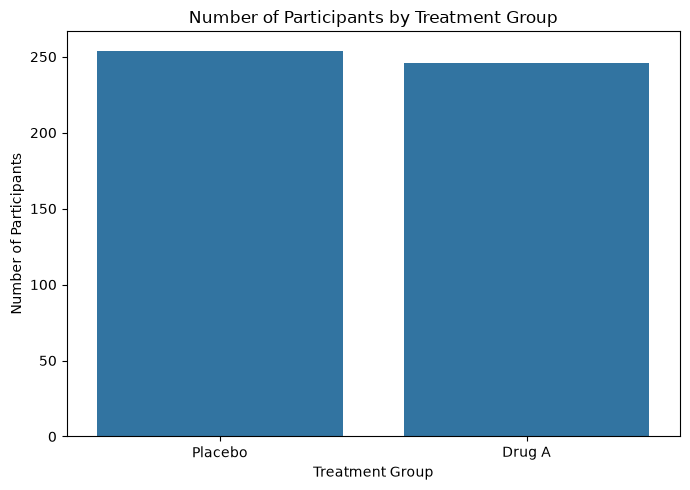

In [36]:
#first chart - treatment distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="treatment_group"
)

plt.title("Number of Participants by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Number of Participants")

plt.tight_layout()
plt.show()